# Try to run code with multiple images

In [ ]:
from src.segmentation_pipeline import convex_segmentation
from src.model_run import start_prediction_machine, detectron2_instances
from src.classic_instances import instance_regions, make_instance_gif
from src.fusion import fusion_of_masks
from src.classifier import classify_instances, load_classifiers, Category_Classifier
from src.coco_json_functions import export_to_coco
from src.model_run import CLASSES
from src.instance_based_evaluation import compare_coco


from sklearn.base import TransformerMixin, BaseEstimator
class SelectColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, xs, ys, **params):
        return self
    def transform(self, xs):
        return xs[self.columns]
    
import pathlib

In [ ]:
# Image
# img_path = "/home/mellanie/Desktop/pipeline_code/20250129_N4_Plate6_DAG6_1000_L/000018.tif"
img_path = "/home/mellanie/Desktop/annotations/masks_from_manual_annotations/Plate_16/"

# Model to use
model_path = "/home/mellanie/Desktop/container/model/segmentation_models/instance_no_root.pth"

# Classifiers
bmp_cls = "/home/mellanie/Desktop/container/model/classifiers/bumps_embedded_classifier.pkl"
bg_cls = "/home/mellanie/Desktop/container/model/classifiers/bg_regular_classifier.pkl"

In [ ]:
# %%capture

# predictor is the segmentaion model as a variable
predictor = start_prediction_machine(path_to_model=model_path, instance_based=True)

# Make the classifier class
bmp_predictor, bg_predictor = load_classifiers(bmp_cls, bg_cls)
classifier = Category_Classifier(None, None, None, None, bmp_predictor, bg_predictor)


def instance_segmentation_pipeline(img_path):
    
    #1. Classic Segmentation
    #   function returns the mask for the root and the mask for the hairs as seperate variables
    root, hairs = convex_segmentation(img_path, save=False, verbose = False, show_overlay=False)

    #2. Separate Classic Segments by Instance
    #   get a list of each unique instance mask of root hairs
    classic_masks = instance_regions(hairs, root)
    
    #3. Get the Model outputs
    #   Instances is a list of all found instances in the image, including bounding box, mask, label, and label id
    model_instances = detectron2_instances(predictor, img_path)

    #4. Fuseion
    fused_instances = fusion_of_masks(classic_masks, model_instances)

    #5. Classify
    classified_instances = classify_instances(fused_instances, root, img_path, classifier)
    
    # OPTIONAL: Destinguish between classic and model
    classic_instances = [inst for inst in classified_instances if inst["case"] != "C"]
    model_instances = [inst for inst in classified_instances if inst["case"] != "B"]

    export_to_coco(classified_instances, img_path, CLASSES, epsilon=0.5, output_path = "outputs/segmentation_outputs_coco.json")
    export_to_coco(classic_instances, img_path, CLASSES, epsilon=0.5, output_path = "outputs/classic_outputs_coco.json")
    export_to_coco(model_instances, img_path, CLASSES, epsilon=0.5, output_path = "outputs/model_outputs_coco.json")

    return classified_instances

/home/mellanie/miniforge3/envs/py3_image_analysis/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mellanie/miniforge3/envs/py3_image_analysis/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mellanie/miniforge3/envs/py3_image_analysis/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Tr

/home/mellanie/.local/lib/python3.10/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


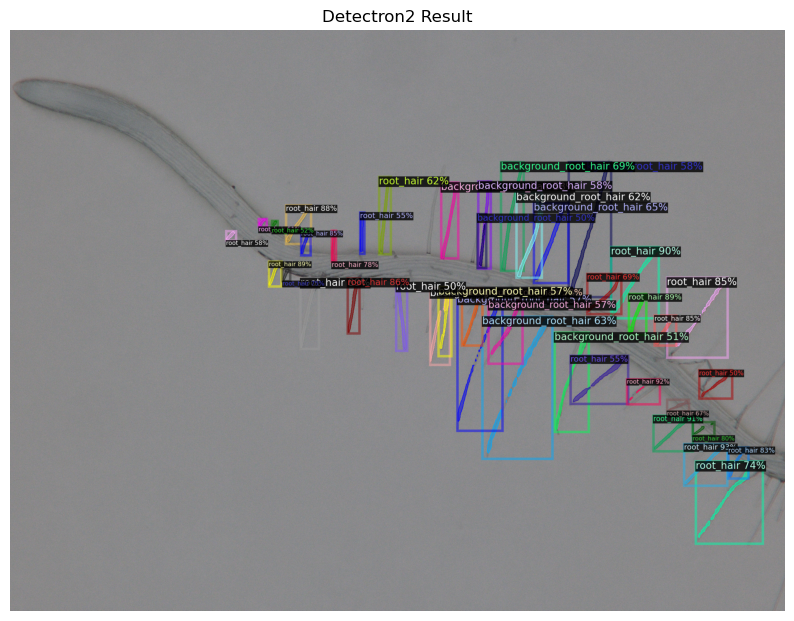

Pairing results:
  Case A (matched):  34
  Case B (classical only): 53
  Case C (DL only): 7


In [ ]:
# %%capture
re = instance_segmentation_pipeline(img_path)

In [5]:
print(f"Number of final Instances: {len(re)}")

Number of final Instances: 52
